In [1]:
# Import the needed libraries

import torch
from torch import nn
from torch.nn import functional as F
import random
import math
import re
import time
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm



import matplotlib.pyplot as plt
import datetime
import os
import zipfile
import shutil
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [2]:
MODE_NAME = "reverse"
REVERSE = True          # <-- the only functional difference from LLMReverse.py
NUMBER_DIGITS = 3
BATCH_SIZE = 100
EPOCHS = 125              # subtraction needs more than the addition-only 15
LEARNING_RATE = 1e-3
NINP, NHEAD, NHID, NLAYERS = 128, 16, 64, 6
 
SEED = 42                 # MUST match LLMReverse.py -- see module docstring
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 50_000, 10_000, 12_000  # test >= 10k (Task 3)
 
random.seed(SEED)
torch.manual_seed(SEED)

### Tokeniser 

In [3]:
pad_token = "[PAD]"
eos_token = "[EOS]"
 
 
class character_level_tokenizer:
    def __init__(self):
        self.vocab = [str(x) for x in range(10)] + ["+", "-", "="] + [pad_token, eos_token]
        self.token_to_id = {v: k for k, v in enumerate(self.vocab)}
        self.id_to_token = {k: v for k, v in enumerate(self.vocab)}
        self.ntokens = len(self.vocab)
        self.pattern = f"[^{re.escape(''.join(self.vocab))}]"
 
    def clean(self, text):
        return re.sub(self.pattern, "", text)
 
    def pre_tokenization(self, text):
        return [c for c in text]
 
    def encode(self, text):
        return [self.token_to_id[c] for c in self.pre_tokenization(self.clean(text))]
 
    def decode(self, token_list):
        return "".join(self.id_to_token[i] for i in token_list)
 
 
tokenizer = character_level_tokenizer()
ntokens = tokenizer.ntokens
EQ_ID = tokenizer.token_to_id["="]
EOS_ID = tokenizer.token_to_id[eos_token]
PAD_ID = tokenizer.token_to_id[pad_token]
print(f"vocab ({ntokens} tokens): {tokenizer.vocab}")

vocab (15 tokens): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', '=', '[PAD]', '[EOS]']


In [4]:
def sample_datapoint(number_digits=3):
    """
    Returns a tuple containing two random numbers and their operator. 
    """
    a_list = [random.randint(0, 9) for _ in range(number_digits)]
    a_int = "".join([str(x) for x in a_list])
 
    b_list = [random.randint(0, 9) for _ in range(number_digits)]
    b_int = "".join([str(x) for x in b_list])
 
    op = random.choice(["+", "-"])
    result_int = int(a_int) + int(b_int) if op == "+" else int(a_int) - int(b_int)
 
    result_str = str(result_int)
    if REVERSE:
        target = ("-" + result_str[1:][::-1]) if result_str.startswith("-") else result_str[::-1]
    else:
        target = result_str
 
    return (str(a_int) + op + str(b_int) + "=", target)

def parse_equation(prompt):
    """Recovers (a_int, b_int, op) from a prompt like '089-957='."""
    op = "+" if "+" in prompt else "-"
    a_str, b_str = prompt.replace("=", "").split(op)
    return int(a_str), int(b_str), op
 
 
def check_carries_or_borrows(a_int, b_int, op, result_int):
    """
    Extends the workshop's check_carries to also handle subtraction (borrows),
    using the same right-to-left column walk. Takes the raw numbers directly
    (rather than a formatted data_tuple) so it works regardless of REVERSE.
    """
    number_digits = len(str(abs(result_int)))
    str_a = str(a_int).zfill(number_digits)
    str_b = str(b_int).zfill(number_digits)
 
    carry_or_borrow = 0
    used_flags = []
    for i in reversed(range(number_digits)):
        digit_a, digit_b = int(str_a[i]), int(str_b[i])
        used_flags.append(1 if carry_or_borrow == 1 else 0)
        if op == "+":
            carry_or_borrow = 1 if (digit_a + digit_b + carry_or_borrow >= 10) else 0
        else:
            carry_or_borrow = 1 if (digit_a - digit_b - carry_or_borrow < 0) else 0
    used_flags.reverse()
    return used_flags
    

### Checking the Sample data

In [5]:
sample = sample_datapoint(3)
print(sample)
a_int, b_int, op = parse_equation(sample[0])
demo_result = a_int + b_int if op == "+" else a_int - b_int
print(check_carries_or_borrows(a_int, b_int, op, demo_result))

('104+332=', '634')
[0, 0, 0]


### Setting the data parameters and creating the TVT

In [6]:
# dataset parameters
number_digits = 3
train_size = 50000
val_size = 10000
test_size = 12000 
 
data = []
while len(data) < (train_size + val_size + test_size):
    sample = sample_datapoint(number_digits)
    if sample not in data:
        data.append(sample)
 
data_train = data[:train_size]
data_val = data[train_size: train_size + val_size]
data_test = data[train_size + val_size: train_size + val_size + test_size]
 
print(len(data_train), len(data_val), len(data_test))
print(data_train[:4], data_val[:4], data_test[:4])
print(set(data_train).intersection(set(data_val)),
      set(data_train).intersection(set(data_test)),
      set(data_val).intersection(set(data_test)))

50000 10000 12000
[('819+600=', '9141'), ('338+908=', '6421'), ('863+794=', '7561'), ('265-423=', '-851')] [('397-005=', '293'), ('162-649=', '-784'), ('348-348=', '0'), ('378+230=', '806')] [('769+203=', '279'), ('405+805=', '0121'), ('927-020=', '709'), ('493+361=', '458')]
set() set() set()


### Positional Encoding 

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(1e4) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)
 
    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)
 
 
class CustomEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.attn_weights = None
 
    def forward(self, src, src_mask=None, src_key_padding_mask=None, **kwargs):
        src2, attn_weights = self.self_attn(
            src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask,
            need_weights=True, average_attn_weights=False,
        )
        self.attn_weights = attn_weights
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

### Building the model 

In [8]:
class TransformerModel(nn.Module):
    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5):
        super().__init__()
        self.input_emb = nn.Embedding(ntoken, ninp)
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = CustomEncoderLayer(ninp, nhead, nhid, 0.1)
        self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(ninp, ntoken)
        self.ninp = ninp
        self.init_weights()
 
    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.input_emb.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)
 
    def _generate_square_subsequent_mask(self, sz):
        return torch.log(torch.tril(torch.ones(sz, sz)))
 
    def forward(self, src):
        mask = self._generate_square_subsequent_mask(len(src)).to(src.device)
        output_enc = self.input_emb(src) * math.sqrt(self.ninp)
        output_enc = self.pos_encoder(output_enc)
        output_enc = self.encoder(output_enc, mask=mask)
        output_dec = self.decoder(output_enc)
        attention_maps = [layer.attn_weights for layer in self.encoder.layers]
        return F.log_softmax(output_dec, dim=-1), output_enc, attention_maps
 
 
model = TransformerModel(ntoken=ntokens, ninp=NINP, nhead=NHEAD, nhid=NHID, nlayers=NLAYERS).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.1)
print(f"parameters: {sum(p.numel() for p in model.parameters())}")

/tmp/ipykernel_1699/2820585398.py:7: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layers, nlayers)


parameters: 502671


### Handling Functions 

In [9]:
def generate(prompts, new_tokens=5):
    input_tensor = prompts.to(device)
    for _ in range(new_tokens):
        output, _, _ = model(input_tensor)
        last_output = output[-1, :, :]
        token = torch.argmax(last_output, -1).view((1, -1))
        input_tensor = torch.cat((input_tensor, token), 0)
    return input_tensor
 
 
def pad(token_list, type_list="prompts"):
    assert type_list in ["prompts", "answers"]
    max_length = max(len(x) for x in token_list)
    out = []
    for x in token_list:
        if type_list == "prompts":
            out.append([tokenizer.token_to_id[pad_token]] * (max_length - len(x)) + x)
        if type_list == "answers":
            out.append(x + [tokenizer.token_to_id[eos_token]] + [tokenizer.token_to_id[pad_token]] * (max_length - len(x)))
    return out, max_length
 
 
def get_batch(data, i, batch_size=BATCH_SIZE):
    prompts = [tokenizer.encode(data[i][0]) for i in range(i, i + batch_size)]
    padded_prompts, length_prompts = pad(prompts, "prompts")
    answers = [tokenizer.encode(data[i][1]) for i in range(i, i + batch_size)]
    padded_answers, length_answers = pad(answers, "answers")
    X = torch.stack([torch.tensor(x) for x in padded_prompts], 1)
    Y = torch.stack([torch.tensor(x) for x in padded_answers], 1)
    return X, Y, length_prompts, length_answers

### Predictions and evaluiations

In [10]:
def predict_sample(prompt, max_new_tokens=6):
    """max_new_tokens=6 covers the largest possible target: sign + up to 4
    digits + [EOS] (e.g. '-1998[EOS]')."""
    prompt_tensor = torch.tensor(tokenizer.encode(prompt)).view((-1, 1))
    output_tensor = generate(prompt_tensor, max_new_tokens)[:, 0]
    output_list = output_tensor.tolist()
    try:
        pred_tokens = output_list[output_list.index(EQ_ID) + 1:]
        if EOS_ID in pred_tokens:
            pred_tokens = pred_tokens[: pred_tokens.index(EOS_ID)]
        pred_str = tokenizer.decode(pred_tokens)
        return parse_target_string(pred_str)
    except (ValueError, IndexError):
        return None
 
 
def evaluate(input_data):
    """Token-level + sequence-level accuracy (agnostic to sign/reverse since it
    compares raw token ids)."""
    model.eval()
    correct_digit, total_digit, correct, total = 0.0, 0.0, 0.0, 0.0
    with torch.no_grad():
        for i in range(0, len(input_data) - 1, BATCH_SIZE):
            if i + BATCH_SIZE > len(input_data):
                break
            prompts, target_answers, length_prompts, length_answers = get_batch(input_data, i)
            prompts = prompts.to(device)
            target_answers = target_answers.to(device)
            output = generate(prompts, length_answers + 1)
            answers_tokens = output[length_prompts:, :]
            target_mask_pad = target_answers != PAD_ID
            equality_test = answers_tokens == target_answers
            correct_digit += torch.logical_and(target_mask_pad, equality_test).sum().item()
            total_digit += target_mask_pad.sum().item()
            correct += torch.all(torch.logical_or(~target_mask_pad, equality_test), dim=0).float().sum().item()
            total += target_answers.shape[-1]
    return correct_digit / total_digit, correct / total
 
 
def error_test(input_data):
    """
    Extends the workshop's errorTest: converts model predictions and targets
    to integers for a whole dataset, batch by batch (faster than calling
    predict_sample example-by-example). Used for the predicted-vs-target
    scatter plot below. Handles the sign token and REVERSE mode via
    parse_target_string, the same logic predict_sample uses.
    """
    model.eval()
    num_ans, num_tgt = [], []
    with torch.no_grad():
        for i in range(0, len(input_data) - 1, BATCH_SIZE):
            if i + BATCH_SIZE > len(input_data):
                break
            prompts, target_answers, length_prompts, length_answers = get_batch(input_data, i)
            prompts = prompts.to(device)
            target_answers = target_answers.to(device)
            output = generate(prompts, length_answers + 1)
            answers_tokens = output[length_prompts:, :]
 
            n_d, n_b = answers_tokens.shape
            for b in range(n_b):
                ans = tokenizer.decode(answers_tokens[:, b].tolist())
                tgt = tokenizer.decode(target_answers[:, b].tolist())
                ans_cleaned = ans.replace(eos_token, "").replace(pad_token, "")
                tgt_cleaned = tgt.replace(eos_token, "").replace(pad_token, "")
 
                ans_int = parse_target_string(ans_cleaned)
                tgt_int = parse_target_string(tgt_cleaned)
                num_ans.append(ans_int if ans_int is not None else 0)
                num_tgt.append(tgt_int if tgt_int is not None else 0)
 
    return torch.tensor(num_ans), torch.tensor(num_tgt)

### Training Loop 

In [11]:
def train_epoch(epoch):
    model.train()
    total_loss = 0.
    n_batch = 0
    iterable = range(0, len(data_train) - 1, BATCH_SIZE)
    for batch, i in tqdm(enumerate(iterable), total=len(iterable), colour="GREEN"):
        n_batch += 1
        prompts, target_answers, length_prompts, length_answers = get_batch(data_train, i)
        prompts = prompts.to(device)
        target_answers = target_answers.to(device)
        input_tensor = torch.cat((prompts, target_answers), 0)
        optimizer.zero_grad()
 
        output, _, _ = model(input_tensor)
        output_answers = output[length_prompts - 1:-1, :, :].reshape(-1, ntokens)
        target_answers = target_answers.view(-1)
 
        loss = F.cross_entropy(output_answers, target_answers)
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item()
 
    total_loss /= n_batch
    train_digit_accuracy, train_seq_accuracy = evaluate(data_train)
 
    return total_loss, train_digit_accuracy, train_seq_accuracy
 
 
def test_epoch(epoch=1):
    model.eval()
    total_loss = 0.
    n_batch = 0
    iterable = range(0, len(data_val) - 1, BATCH_SIZE)
    for batch, i in tqdm(enumerate(iterable), total=len(iterable)):
        n_batch += 1
        prompts, target_answers, length_prompts, length_answers = get_batch(data_val, i)
        prompts = prompts.to(device)
        target_answers = target_answers.to(device)
        input_tensor = torch.cat((prompts, target_answers), 0)
 
        with torch.no_grad():
            output, _, _ = model(input_tensor)
        output_answers = output[length_prompts - 1:-1, :, :].reshape(-1, ntokens)
        target_answers = target_answers.view(-1)
 
        loss = F.cross_entropy(output_answers, target_answers)
        total_loss += loss.item()
 
    total_loss /= n_batch
    test_digit_accuracy, test_seq_accuracy = evaluate(data_val)
 
    return total_loss, test_digit_accuracy, test_seq_accuracy
 
 
def train():
    train_losses4disp = []
    test_losses4disp = []
    test_digit_accuracy4disp = []
    train_digit_accuracy4disp = []
    test_seq_accuracy4disp = []
    train_seq_accuracy4disp = []
 
    test_digit_accuracy, test_seq_accuracy = evaluate(data_val)
    print("-" * 89)
    print(f"[{MODE_NAME}] | initialisation | val digit accuracy {test_digit_accuracy:5.3f} "
          f"| val seq accuracy {test_seq_accuracy:5.3f}")
    print("-" * 89)
 
    training_start_time = time.time()
    for epoch in range(1, EPOCHS + 1):
        epoch_start_time = time.time()
        train_loss, train_digit_accuracy, train_seq_accuracy = train_epoch(epoch)
        test_loss, test_digit_accuracy, test_seq_accuracy = test_epoch(epoch)
 
        train_losses4disp.append(train_loss)
        test_losses4disp.append(test_loss)
        train_digit_accuracy4disp.append(train_digit_accuracy)
        test_digit_accuracy4disp.append(test_digit_accuracy)
        train_seq_accuracy4disp.append(train_seq_accuracy)
        test_seq_accuracy4disp.append(test_seq_accuracy)
 
        str_epoch = (f"Epoch {epoch:3d} ({time.time()-epoch_start_time:5.2f}s), "
                     f"val digit accuracy:{test_digit_accuracy:5.3f}, val seq accuracy:{test_seq_accuracy:5.3f}, "
                     f"train digit accuracy:{train_digit_accuracy:5.3f}, train seq accuracy:{train_seq_accuracy:5.3f}, "
                     f"loss:{train_loss:5.3}")
        print(f"[{MODE_NAME}] {str_epoch}")
 
    total_training_time = (time.time() - training_start_time) / 60
    str_time = f"Total training time: {total_training_time:.2f} min\n"
    print(str_time)
    return (np.array(train_losses4disp), np.array(test_losses4disp),
            np.array(test_digit_accuracy4disp), np.array(train_digit_accuracy4disp),
            np.array(test_seq_accuracy4disp), np.array(train_seq_accuracy4disp),
            (str_epoch, str_time))
 
 
datename = datetime.datetime.now().strftime("%Yy%mm%dd-%Hh%Mm%Ss")
gen_name = f"{datename}-{MODE_NAME.capitalize()}AddSubLM"
 
print(f"\n=== Training {MODE_NAME} model ({EPOCHS} epochs) ===")
(train_losses4disp, test_losses4disp,
 test_digit_accuracy4disp, train_digit_accuracy4disp,
 test_seq_accuracy4disp, train_seq_accuracy4disp, str_results) = train()
str_epoch, str_time = str_results
 
torch.save(model.state_dict(), gen_name + ".pkl")
 
# keep a dict view of the same arrays for the rest of the file (export, etc.)
history = {
    "train_loss": train_losses4disp.tolist(), "val_loss": test_losses4disp.tolist(),
    "train_digit_acc": train_digit_accuracy4disp.tolist(), "val_digit_acc": test_digit_accuracy4disp.tolist(),
    "train_seq_acc": train_seq_accuracy4disp.tolist(), "val_seq_acc": test_seq_accuracy4disp.tolist(),
}
 
test_digit_acc, test_seq_acc = evaluate(data_test)
print(f"[{MODE_NAME}] held-out test: digit_acc={test_digit_acc:.4f} seq_acc={test_seq_acc:.4f}")
if test_seq_acc < 0.78:
    print(f"[{MODE_NAME}] NOTE: {test_seq_acc:.2%} is below the assignment's 0.78 target. "
          f"If val_seq_acc was still climbing at the last epoch (check the plot below), "
          f"increase EPOCHS and rerun.")


=== Training reverse model (125 epochs) ===
-----------------------------------------------------------------------------------------
[reverse] | initialisation | val digit accuracy 0.000 | val seq accuracy 0.000
-----------------------------------------------------------------------------------------


100%|██████████| 100/100 [00:01<00:00, 80.17it/s]


[reverse] Epoch   1 (46.19s), val digit accuracy:0.449, val seq accuracy:0.005, train digit accuracy:0.450, train seq accuracy:0.005, loss: 1.47


100%|██████████| 100/100 [00:01<00:00, 74.78it/s]


[reverse] Epoch   2 (46.05s), val digit accuracy:0.496, val seq accuracy:0.006, train digit accuracy:0.498, train seq accuracy:0.008, loss: 1.14


...

[reverse] Epoch 123 (21.03s), val digit accuracy:0.758, val seq accuracy:0.101, train digit accuracy:0.759, train seq accuracy:0.110, loss:0.491


100%|██████████| 100/100 [00:00<00:00, 184.84it/s]


[reverse] Epoch 124 (21.04s), val digit accuracy:0.752, val seq accuracy:0.103, train digit accuracy:0.754, train seq accuracy:0.108, loss:0.492


100%|██████████| 100/100 [00:00<00:00, 184.98it/s]


[reverse] Epoch 125 (21.03s), val digit accuracy:0.755, val seq accuracy:0.104, train digit accuracy:0.757, train seq accuracy:0.111, loss:0.491
Total training time: 58.27 min

[reverse] held-out test: digit_acc=0.7540 seq_acc=0.1004
[reverse] NOTE: 10.04% is below the assignment's 0.78 target. If val_seq_acc was still climbing at the last epoch (check the plot below), increase EPOCHS and rerun.


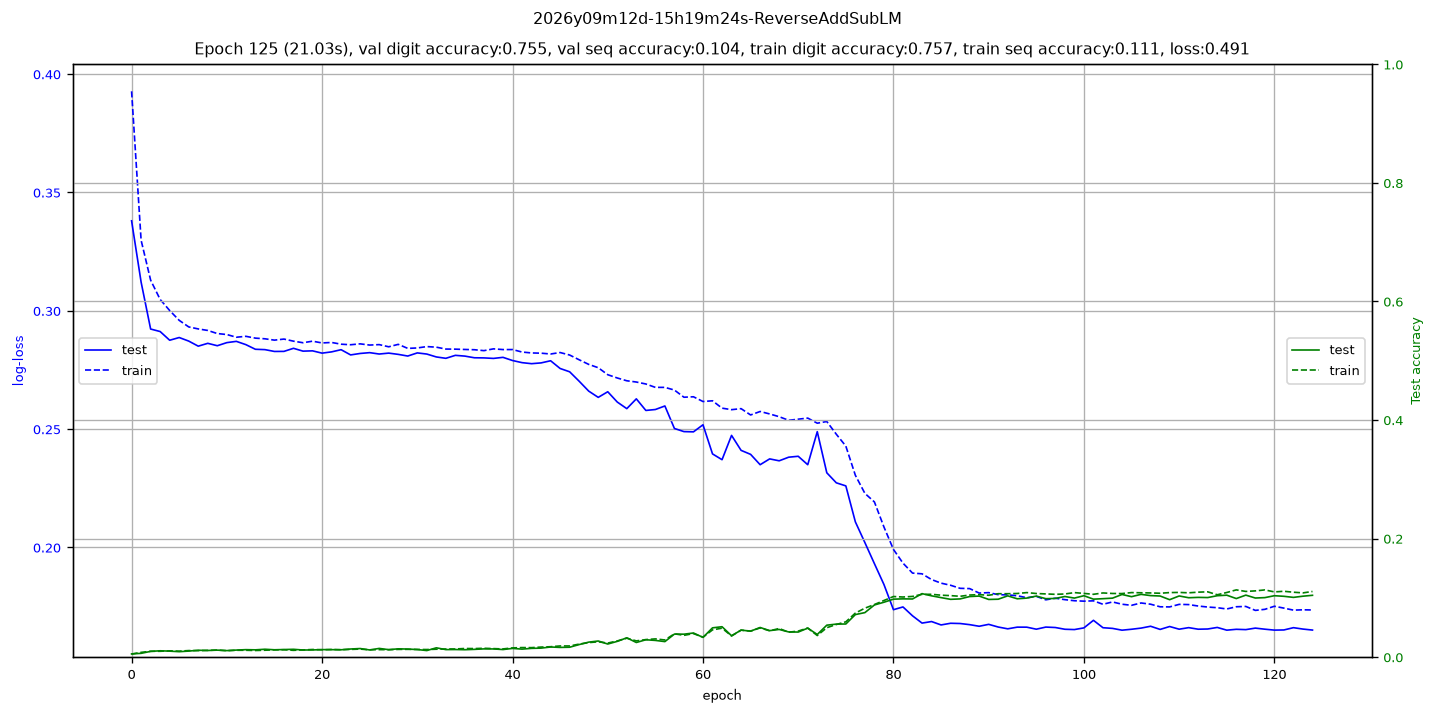

saved reverse_training_curves.png


In [12]:
f = plt.figure(figsize=(12, 6), dpi=120)
plt.rc("font", size=8)
 
ax = f.add_subplot(1, 1, 1)
ax.plot(np.log10(1. + test_losses4disp), color="b", label="test", linewidth=1)
ax.plot(np.log10(1. + train_losses4disp), color="b", linestyle="--", label="train", linewidth=1)
ax.set_xlabel("epoch")
ax.set_ylabel("log-loss", color="b")
ax.tick_params(axis="y", labelcolor="b")
ax.set_title(str_epoch)
ax.legend(loc="center left")
plt.grid()
 
ax2 = ax.twinx()
ax2.plot(test_seq_accuracy4disp, color="green", label="test", linewidth=1)
ax2.plot(train_seq_accuracy4disp, color="green", linestyle="--", label="train", linewidth=1)
ax2.set_xlabel("epoch")
ax2.set_ylabel("Test accuracy", color="green")
ax2.tick_params(axis="y", labelcolor="green")
ax2.legend(loc="center right")
ax2.set_ylim((0, 1))
plt.grid()
 
f.suptitle(gen_name)
plt.tight_layout()
plt.savefig(f"{MODE_NAME}_training_curves.png", dpi=150)
plt.show()
print(f"saved {MODE_NAME}_training_curves.png")

In [13]:
def format_target_string(result_int): 
    s = str(result_int)
    if REVERSE:
        return ("-" + s[1:][::-1]) if s.startswith("-") else s[::-1]
    return s

def parse_target_string(s):
    if s in ("", "-"):
        return None
    if s.startswith("-"):
        s = "-" + (s[1:][::-1] if REVERSE else s[1:])
    elif REVERSE:
        s = s[::-1]
    try:
        return int(s)
    except ValueError:
        return None

In [14]:
rows = []
model.eval()
for prompt, _ in tqdm(data_test, desc=f"eval-{MODE_NAME}"):
    a_int, b_int, op = parse_equation(prompt)
    true_result = a_int + b_int if op == "+" else a_int - b_int
    pred = predict_sample(prompt)
    correct = (pred == true_result)
 
    true_str = str(abs(true_result)).zfill(4)
    pred_str = str(abs(pred)).zfill(4) if pred is not None else "----"
    digit_correct = [pred_str[i] == true_str[i] for i in range(4)] if pred is not None else [False] * 4
    sign_correct = (pred is not None) and ((pred < 0) == (true_result < 0))
    carries = check_carries_or_borrows(a_int, b_int, op, true_result)
 
    rows.append({
        "mode": MODE_NAME, "a": a_int, "b": b_int, "op": op,
        "true_result": true_result, "pred_result": pred, "correct": correct,
        "sign_correct": sign_correct,
        "thousands_correct": digit_correct[0], "hundreds_correct": digit_correct[1],
        "tens_correct": digit_correct[2], "units_correct": digit_correct[3],
        "has_carry_or_borrow": sum(carries) > 0,
        "n_carries_or_borrows": sum(carries),
        "result_length": len(str(abs(true_result))),
        "operand_length": max(len(str(a_int)), len(str(b_int))),
    })
 
eval_df = pd.DataFrame(rows)

eval-reverse: 100%|██████████| 12000/12000 [02:47<00:00, 71.80it/s]



[reverse] EVALUATION SUMMARY  (n=12000 held-out test examples)

Overall exact-match accuracy: 0.1004  (BELOW 0.78 TARGET)

--- Operation robustness (accuracy by operation) ---
    accuracy  count
op                 
+   0.097573   5934
-   0.103198   6066

--- Digit-position accuracy (units / tens / hundreds / thousands) ---
thousands_correct    0.998750
hundreds_correct     0.984583
tens_correct         0.835667
units_correct        0.100500
Name: accuracy, dtype: float64

--- Digit-position accuracy, split by operation ---
    thousands_correct  hundreds_correct  tens_correct  units_correct
op                                                                  
+            0.997472          0.983485      0.850354       0.097573
-            1.000000          0.985658      0.821299       0.103363

--- Accuracy vs. presence of a carry/borrow ---
                     accuracy  count
has_carry_or_borrow                 
False                0.083227   3148
True                 0.106530   

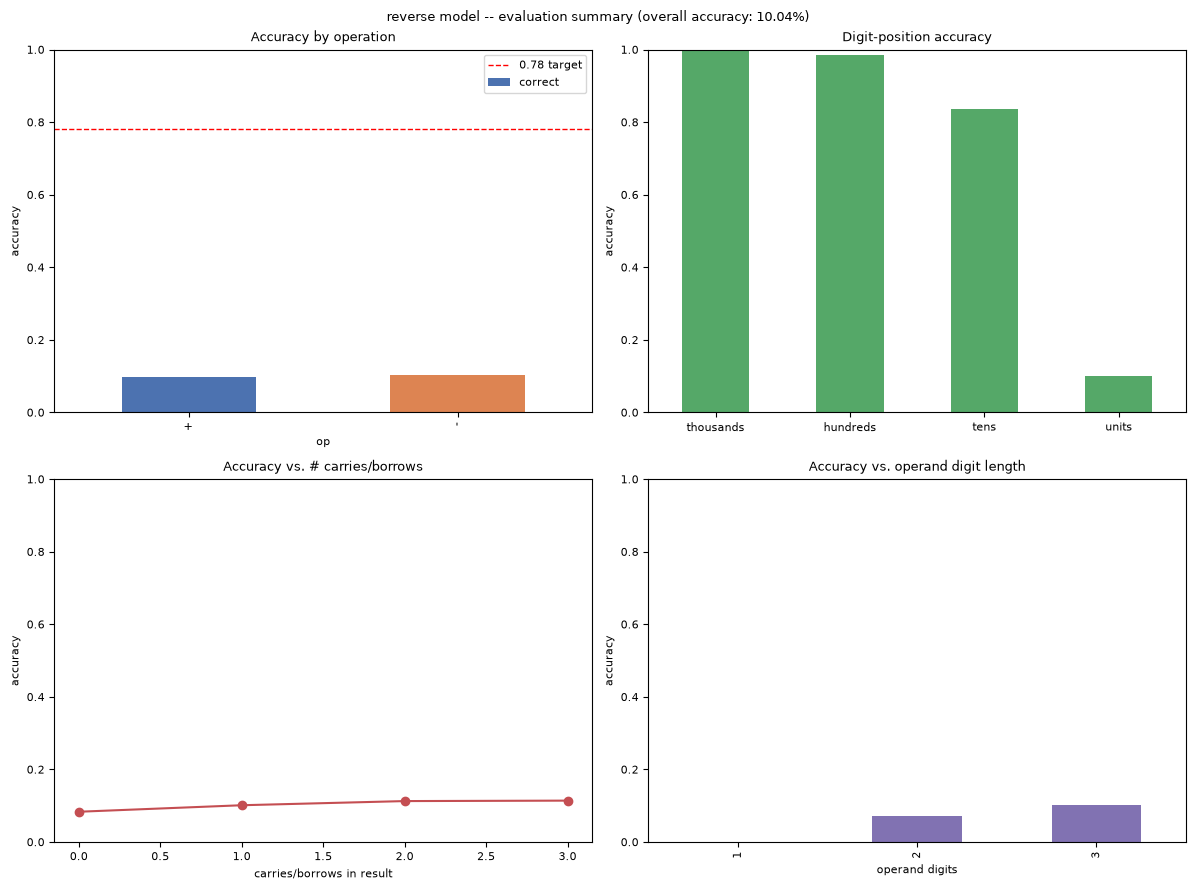


saved reverse_evaluation_summary.png


In [15]:
digit_cols = ["thousands_correct", "hundreds_correct", "tens_correct", "units_correct"]
 
overall_acc = eval_df["correct"].mean()
print(f"\n{'='*70}\n[{MODE_NAME}] EVALUATION SUMMARY  (n={len(eval_df)} held-out test examples)\n{'='*70}")
 
print(f"\nOverall exact-match accuracy: {overall_acc:.4f}  "
      f"({'PASS' if overall_acc >= 0.78 else 'BELOW 0.78 TARGET'})")
 
print("\n--- Operation robustness (accuracy by operation) ---")
print(eval_df.groupby("op")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy"}))
 
print("\n--- Digit-position accuracy (units / tens / hundreds / thousands) ---")
print(eval_df[digit_cols].mean().rename("accuracy"))
 
print("\n--- Digit-position accuracy, split by operation ---")
print(eval_df.groupby("op")[digit_cols].mean())
 
print("\n--- Accuracy vs. presence of a carry/borrow ---")
print(eval_df.groupby("has_carry_or_borrow")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy"}))
 
print("\n--- Accuracy vs. number of carries/borrows in the result ---")
print(eval_df.groupby("n_carries_or_borrows")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy"}))
 
print("\n--- Accuracy vs. operand digit length ---")
print(eval_df.groupby("operand_length")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy"}))
 
neg_examples = eval_df[eval_df["true_result"] < 0]
print(f"\n--- Sign accuracy on negative-result (subtraction) examples, n={len(neg_examples)} ---")
if len(neg_examples) > 0:
    print(f"sign_correct rate: {neg_examples['sign_correct'].mean():.4f}")
 
# --- plots ---
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(f"{MODE_NAME} model -- evaluation summary (overall accuracy: {overall_acc:.2%})")
 
eval_df.groupby("op")["correct"].mean().plot(kind="bar", ax=axes[0, 0], color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Accuracy by operation"); axes[0, 0].set_ylim(0, 1); axes[0, 0].set_ylabel("accuracy")
axes[0, 0].axhline(0.78, color="red", linestyle="--", linewidth=1, label="0.78 target")
axes[0, 0].legend()
 
eval_df[digit_cols].mean().plot(kind="bar", ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Digit-position accuracy"); axes[0, 1].set_ylim(0, 1); axes[0, 1].set_ylabel("accuracy")
axes[0, 1].set_xticklabels(["thousands", "hundreds", "tens", "units"], rotation=0)
 
eval_df.groupby("n_carries_or_borrows")["correct"].mean().plot(ax=axes[1, 0], marker="o", color="#C44E52")
axes[1, 0].set_title("Accuracy vs. # carries/borrows"); axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_xlabel("carries/borrows in result"); axes[1, 0].set_ylabel("accuracy")
 
eval_df.groupby("operand_length")["correct"].mean().plot(kind="bar", ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Accuracy vs. operand digit length"); axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_xlabel("operand digits"); axes[1, 1].set_ylabel("accuracy")
 
plt.tight_layout()
plt.savefig(f"{MODE_NAME}_evaluation_summary.png", dpi=150)
plt.show()
print(f"\nsaved {MODE_NAME}_evaluation_summary.png")